# Angie EDA + SHAP for wildfire drivers

Goals:
- Univariate, bivariate, multivariate analysis and correlation matrix
- SHAP feature impact and threshold analysis for wildfire events
- Clean data (remove nulls) and reduce low-importance variables

Datasets (all under /archive/Angie): waterbody, storm/vegetation/soil moisture, lightning (GOES), wildfire history.

## 1. Load Parquet sources from /Angie

This notebook loads:
- s1_water_alberta_30km_monthly_2020-2025.parquet
- alberta_grid30000m_weekly_WITHstorm_SMAP_MODISQA_2020-2025.parquet
- noaa_goes_alberta_2024_07.parquet
- wildfires_core_clean_2020_2025.parquet

In [1]:
# Optional: run once if needed
# %pip install pandas numpy seaborn matplotlib scikit-learn shap pyarrow

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

In [7]:
BASE = Path(r"C:\Users\Angie\Downloads\paragon\Paragon\archive\Angie")
YEARS = list(range(2020, 2026))


def safe_read_parquet(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"Missing: {path}")
        return pd.DataFrame()
    return pd.read_parquet(path)


def load_yearly(folder: str, pattern: str, years=YEARS) -> pd.DataFrame:
    frames = []
    for year in years:
        path = BASE / folder / pattern.format(year=year)
        if path.exists():
            frames.append(pd.read_parquet(path))
        else:
            print(f"Missing: {path.name}")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


waterbody = load_yearly("waterbody", "s1_water_alberta_30km_monthly_{year}.parquet")
storm = load_yearly(
    "storm_vegetation_soil_moisture",
    "alberta_grid30000m_weekly_WITHstorm_SMAP_MODISQA_{year}.parquet",
)
lightning = safe_read_parquet(BASE / "lightning" / "noaa_goes_alberta_2024_07.parquet")
wildfire = safe_read_parquet(BASE / "historical_wildfire" / "wildfires_core_clean_2020_2025.parquet")

In [8]:
def df_summary(name: str, df: pd.DataFrame) -> None:
    print(f"{name}: shape={df.shape}")
    if df.empty:
        return
    display(df.head(3))
    print("Columns:")
    print(sorted(df.columns))


df_summary("waterbody", waterbody)
df_summary("storm", storm)
df_summary("lightning", lightning)
df_summary("wildfire", wildfire)

waterbody: shape=(4415, 16)


,system:index,grid_m,lat,lon,month,orbit_pass,s1_platform,s1_scenes_in_month,slope_max_deg,vv_db_thresh,water_frac,x_idx,y_idx,year,ym,.geo
0,0_0,30000,52.101597,-117.408155,1,ALL,A,42,10,-17,0.0,0,0,2020,2020-01,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,0_1,30000,52.207345,-116.999636,1,ALL,A,42,10,-17,0.0,0,0,2020,2020-01,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,0_2,30000,52.311506,-116.588918,1,ALL,A,42,10,-17,0.0,0,0,2020,2020-01,"{""type"":""MultiPoint"",""coordinates"":[]}"


Columns:
['.geo', 'grid_m', 'lat', 'lon', 'month', 'orbit_pass', 's1_platform', 's1_scenes_in_month', 'slope_max_deg', 'system:index', 'vv_db_thresh', 'water_frac', 'x_idx', 'y_idx', 'year', 'ym']
storm: shape=(285175, 32)


,system:index,aspect_deg,cape_max,cell_id,d2m_mean_K,elev_m,end_date,et_flux_mean,gust_max_mps,lat,lon,rain_mmhr_max,slope_deg,sm_rootzone_mean,sm_rootzone_min,sm_surface_mean,sm_surface_min,smap_surface_temp_mean,sp_mean_Pa,start_date,storm_hours_cape500,storm_hours_gust20,storm_hours_rain5,storm_score,t2m_mean_K,tp_sum_m,water_perm_frac,water_season_frac,wind10_mean_mps,.geo,evi_median,ndvi_median
0,"0_162,53",104.0,17.380371,"162,53",267.232718,835.0,1/7/2020,0.000006,22.539396,48.857139,-110.164432,0.473013,0.0,0.270862,0.268987,0.252565,0.241472,271.366211,90448.53913,1/1/2020,0.0,2.0,0.0,0.783654,271.428963,0.005731,0.0,1.0,3.100354,"{""type"":""MultiPoint"",""coordinates"":[]}",NaN,NaN
1,"0_163,53",182.0,11.661865,"163,53",267.003895,875.0,1/7/2020,0.000004,21.222826,48.932848,-109.771914,0.354173,0.0,0.258985,0.258777,0.234047,0.230458,267.906036,90514.63139,1/1/2020,0.0,2.0,0.0,0.730967,270.968262,0.005109,0.0,1.0,3.101090,"{""type"":""MultiPoint"",""coordinates"":[]}",NaN,NaN
2,"0_159,54",NaN,NaN,"159,54",NaN,NaN,1/7/2020,NaN,NaN,48.877533,-111.456501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1/1/2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""type"":""MultiPoint"",""coordinates"":[]}",NaN,NaN


Columns:
['.geo', 'aspect_deg', 'cape_max', 'cell_id', 'd2m_mean_K', 'elev_m', 'end_date', 'et_flux_mean', 'evi_median', 'gust_max_mps', 'lat', 'lon', 'ndvi_median', 'rain_mmhr_max', 'slope_deg', 'sm_rootzone_mean', 'sm_rootzone_min', 'sm_surface_mean', 'sm_surface_min', 'smap_surface_temp_mean', 'sp_mean_Pa', 'start_date', 'storm_hours_cape500', 'storm_hours_gust20', 'storm_hours_rain5', 'storm_score', 'system:index', 't2m_mean_K', 'tp_sum_m', 'water_perm_frac', 'water_season_frac', 'wind10_mean_mps']
lightning: shape=(952, 5)


,timestamp,latitude,longitude,data_source,energy
0,2024-07-01 00:00:03.033494+00:00,51.413387,-114.415314,GOES-18,7.128487e-14
1,2024-07-01 00:00:04.158847+00:00,50.527981,-114.168358,GOES-18,6.728488e-14
2,2024-07-01 00:00:05.104144+00:00,54.090260,-115.542870,GOES-18,4.128498e-14


Columns:
['data_source', 'energy', 'latitude', 'longitude', 'timestamp']
wildfire: shape=(5564, 10)


,year,fire_number,fire_start_date,start_month,start_doy,latitude,longitude,fire_origin,general_cause,grid_id_30000m
0,2020,LWF064,2020-05-15 14:15:00,5.0,136.0,55.929466,-110.738365,Indian Reservation,Resident,"169,79"
1,2020,GWF016,2020-05-28 20:20:00,5.0,149.0,55.490551,-118.388000,Provincial Land,Incendiary,"153,83"
2,2020,SWF031,2020-06-02 13:05:00,6.0,154.0,55.914551,-113.928650,Indian Reservation,Power Line Industry,"163,81"


Columns:
['fire_number', 'fire_origin', 'fire_start_date', 'general_cause', 'grid_id_30000m', 'latitude', 'longitude', 'start_doy', 'start_month', 'year']


## 2. Basic data cleaning and null handling

Drop columns with >60% missing and rows with >20% missing. Adjust thresholds as needed.

In [9]:
def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df


def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    return (
        df.isna()
        .mean()
        .sort_values(ascending=False)
        .to_frame("missing_fraction")
    )


def drop_missing(df: pd.DataFrame, col_thresh: float = 0.60, row_thresh: float = 0.20) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()
    col_missing = df.isna().mean()
    keep_cols = col_missing[col_missing <= col_thresh].index
    df = df[keep_cols]
    row_missing = df.isna().mean(axis=1)
    df = df.loc[row_missing <= row_thresh].copy()
    return df


waterbody = drop_missing(clean_columns(waterbody))
storm = drop_missing(clean_columns(storm))
lightning = drop_missing(clean_columns(lightning))
wildfire = drop_missing(clean_columns(wildfire))

print("Missingness (top 10):")
for name, df in {
    "waterbody": waterbody,
    "storm": storm,
    "lightning": lightning,
    "wildfire": wildfire,
}.items():
    print(f"\n{name}")
    display(missing_report(df).head(10))

Missingness (top 10):

waterbody


,missing_fraction
system:index,0.0
grid_m,0.0
lat,0.0
lon,0.0
month,0.0
s1_scenes_in_month,0.0
slope_max_deg,0.0
vv_db_thresh,0.0
water_frac,0.0
x_idx,0.0



storm


,missing_fraction
aspect_deg,0.034707
slope_deg,0.034707
elev_m,0.014100
system:index,0.000000
cell_id,0.000000
cape_max,0.000000
d2m_mean_k,0.000000
end_date,0.000000
gust_max_mps,0.000000
et_flux_mean,0.000000



lightning


,missing_fraction
timestamp,0.0
latitude,0.0
longitude,0.0
data_source,0.0
energy,0.0



wildfire


,missing_fraction
fire_origin,0.000539
year,0.000000
fire_number,0.000000
fire_start_date,0.000000
start_doy,0.000000
start_month,0.000000
latitude,0.000000
longitude,0.000000
general_cause,0.000000
grid_id_30000m,0.000000


## 3. Align key columns for joins

This section suggests join keys (date/time, lat/lon, grid id). You can override them manually.

In [10]:
KEY_HINTS = {
    "date": ["date", "datetime", "time", "timestamp", "week", "month", "year"],
    "lat": ["lat", "latitude", "y"],
    "lon": ["lon", "longitude", "x"],
    "grid": ["grid", "grid_id", "cell", "cell_id", "id"],
}


def suggest_keys(df: pd.DataFrame) -> dict:
    cols = set(df.columns)
    return {
        group: [c for c in cols if any(h in c for h in hints)]
        for group, hints in KEY_HINTS.items()
    }


for name, df in {
    "waterbody": waterbody,
    "storm": storm,
    "lightning": lightning,
    "wildfire": wildfire,
}.items():
    print(f"\n{name} key candidates:")
    print(suggest_keys(df))

# Manual override if needed
# Example:
# JOIN_KEYS = {
#     "wildfire": ["event_date", "lat", "lon"],
#     "storm": ["event_date", "lat", "lon"],
#     "waterbody": ["event_date", "lat", "lon"],
#     "lightning": ["event_date", "lat", "lon"],
# }
JOIN_KEYS = {}


waterbody key candidates:
{'date': ['year', 's1_scenes_in_month', 'month'], 'lat': ['year', 'y_idx', 'lat', 'ym', 'system:index'], 'lon': ['x_idx', 'slope_max_deg', 'lon', 'y_idx', 'system:index'], 'grid': ['x_idx', 'y_idx', 'grid_m']}

storm key candidates:
{'date': ['start_date', 'end_date'], 'lat': ['system:index', 'lat'], 'lon': ['et_flux_mean', 'lon', 'system:index', 'rain_mmhr_max', 'gust_max_mps', 'cape_max'], 'grid': ['cell_id']}

lightning key candidates:
{'date': ['timestamp'], 'lat': ['latitude', 'energy'], 'lon': ['longitude'], 'grid': []}

wildfire key candidates:
{'date': ['year', 'start_month', 'fire_start_date'], 'lat': ['year', 'latitude', 'start_doy'], 'lon': ['longitude'], 'grid': ['grid_id_30000m']}


In [11]:
def coerce_datetime(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def try_merge(base: pd.DataFrame, other: pd.DataFrame, keys: list[str], label: str) -> pd.DataFrame:
    if not keys:
        print(f"Skipping merge for {label}: no keys set")
        return base
    missing = [k for k in keys if k not in base.columns or k not in other.columns]
    if missing:
        print(f"Skipping merge for {label}: missing keys {missing}")
        return base
    return base.merge(other, on=keys, how="left")


merged = wildfire.copy()
if JOIN_KEYS:
    merged = try_merge(merged, storm, JOIN_KEYS.get("storm", []), "storm")
    merged = try_merge(merged, waterbody, JOIN_KEYS.get("waterbody", []), "waterbody")
    merged = try_merge(merged, lightning, JOIN_KEYS.get("lightning", []), "lightning")
else:
    # Default path: use storm as base and label wildfire events to get both classes
    if (
        not storm.empty
        and not wildfire.empty
        and "grid_id_30000m" in wildfire.columns
        and "cell_id" in storm.columns
    ):
        storm_base = storm.copy()
        storm_base["grid_id_30000m"] = storm_base["cell_id"]

        storm_date_col = "start_date" if "start_date" in storm_base.columns else "end_date"
        if storm_date_col not in storm_base.columns:
            print("Storm dataset missing start_date/end_date. Using wildfire-only dataset.")
        else:
            storm_base["date_key"] = pd.to_datetime(
                storm_base[storm_date_col], errors="coerce"
            ).dt.date
            wildfire_events = wildfire.copy()
            wildfire_events["date_key"] = pd.to_datetime(
                wildfire_events.get("fire_start_date"), errors="coerce"
            ).dt.date
            wildfire_events["fire_event"] = 1
            wildfire_events = wildfire_events[
                ["grid_id_30000m", "date_key", "fire_event"]
            ].drop_duplicates()

            merged = storm_base.merge(
                wildfire_events, on=["grid_id_30000m", "date_key"], how="left"
            )
            merged["fire_event"] = merged["fire_event"].fillna(0).astype(int)
            print(
                "JOIN_KEYS empty: using storm base with wildfire event labeling on grid_id_30000m + date_key."
            )
    else:
        print("JOIN_KEYS is empty. Using wildfire dataset only for modeling.")

print(f"Merged shape: {merged.shape}")

JOIN_KEYS empty: using storm base with wildfire event labeling on grid_id_30000m + date_key.
Merged shape: (281210, 33)


In [12]:
TARGET_COL = None

def detect_target(df: pd.DataFrame) -> str | None:
    candidates = [
        c
        for c in df.columns
        if any(k in c for k in ["fire", "wildfire", "burn", "event", "is_fire"])
    ]
    return candidates[0] if candidates else None


if "fire_event" in merged.columns:
    TARGET_COL = "fire_event"
elif "fire_number" in merged.columns:
    merged = merged.copy()
    merged["fire_event"] = 1
    TARGET_COL = "fire_event"
else:
    TARGET_COL = detect_target(merged)

print(f"Detected target column: {TARGET_COL}")

df_model = merged.copy()
if TARGET_COL is None:
    print("Set TARGET_COL manually before running bivariate/SHAP sections.")
else:
    # Normalize target to 0/1
    if df_model[TARGET_COL].dtype == "bool":
        df_model[TARGET_COL] = df_model[TARGET_COL].astype(int)
    else:
        df_model[TARGET_COL] = pd.to_numeric(df_model[TARGET_COL], errors="coerce")
        df_model[TARGET_COL] = (df_model[TARGET_COL] > 0).astype(int)

print(f"Modeling shape: {df_model.shape}")

Detected target column: fire_event
Modeling shape: (281210, 33)


In [13]:
if TARGET_COL is not None:
    print("Target value counts:")
    display(df_model[TARGET_COL].value_counts(dropna=False))
else:
    print("TARGET_COL is None. Set it manually (e.g., TARGET_COL = 'fire_occurrence').")

# Optional: quick sanity check for class balance
if TARGET_COL is not None and df_model[TARGET_COL].nunique() < 2:
    print("Only one class present. This usually means:")
    print("1) TARGET_COL is wrong, or")
    print("2) The join logic filtered out non-fire or fire rows.")
    print("Try setting JOIN_KEYS and re-merge, or set TARGET_COL manually.")

Target value counts:


fire_event
0    281136
1        74
Name: count, dtype: int64

## 4. Univariate EDA (vegetation health, soil moisture, waterbody, lightning, ERA5/EDA5)

Plots are limited to a subset of columns for speed.

Univariate: merged dataset


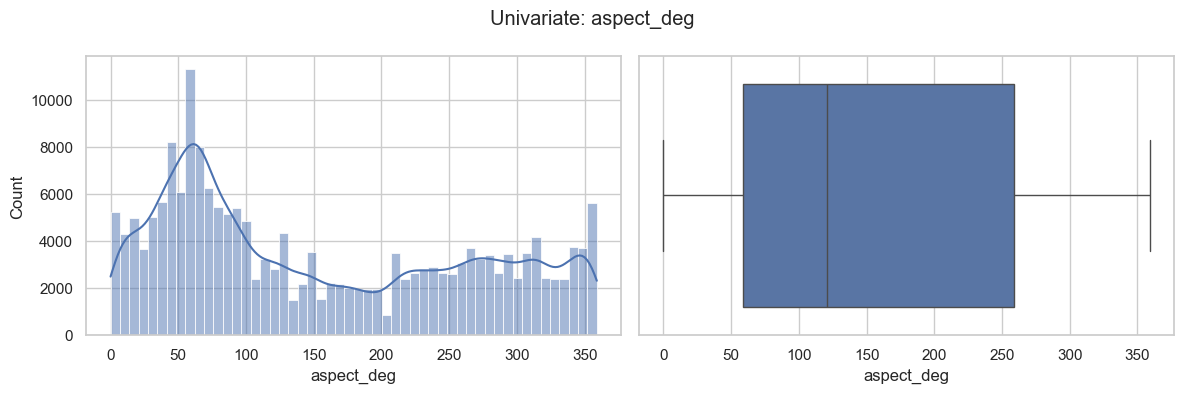

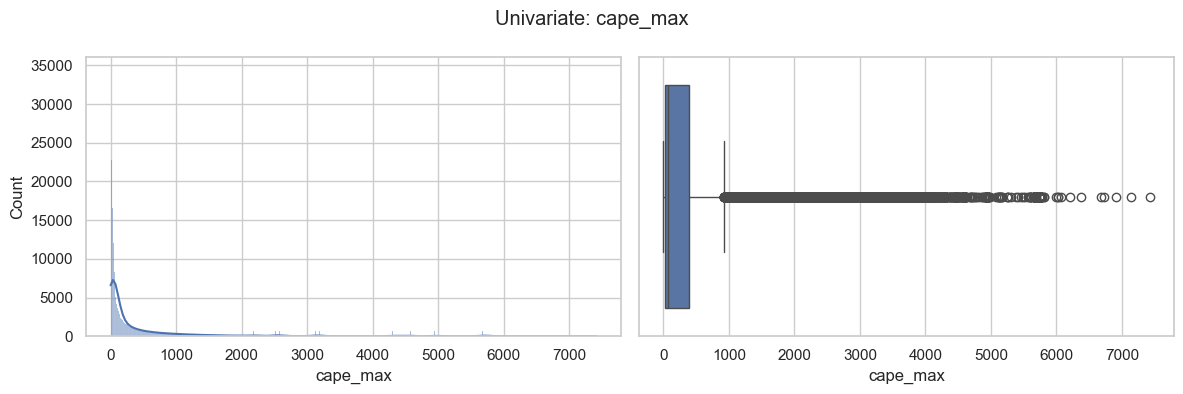

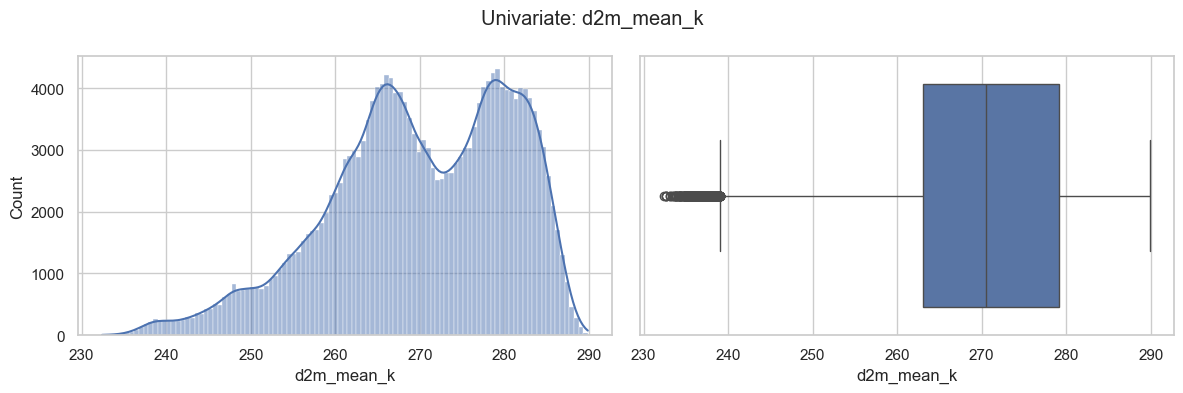

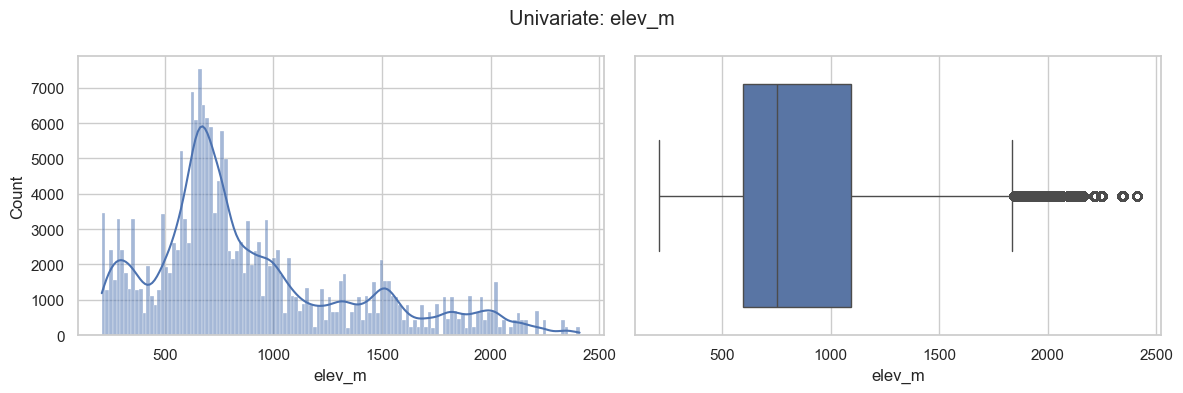

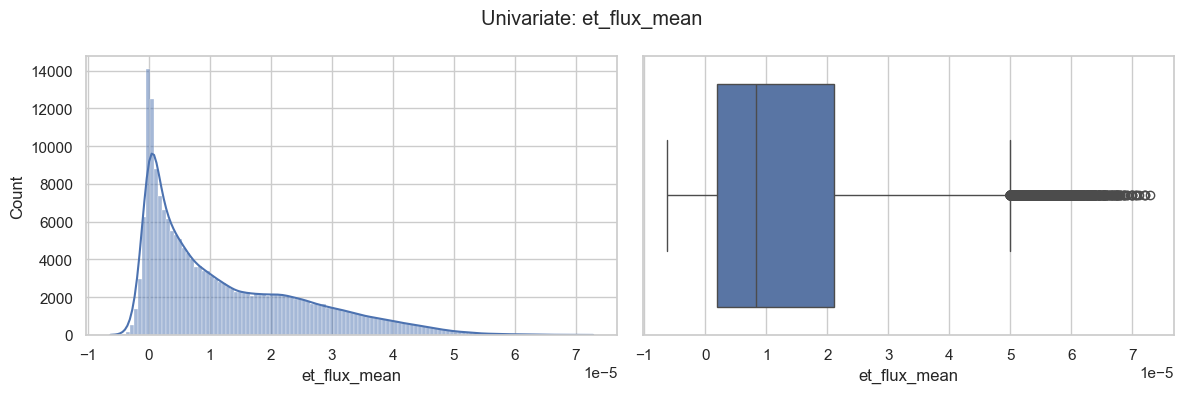

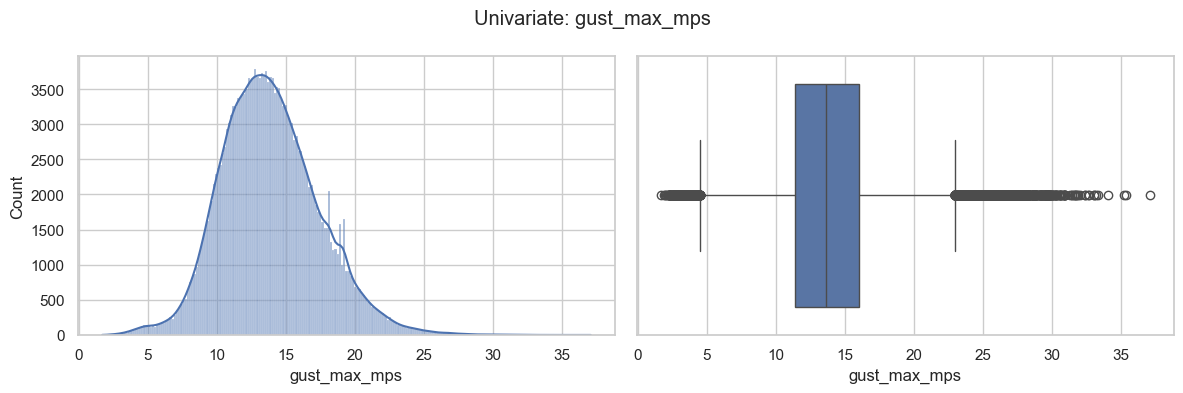

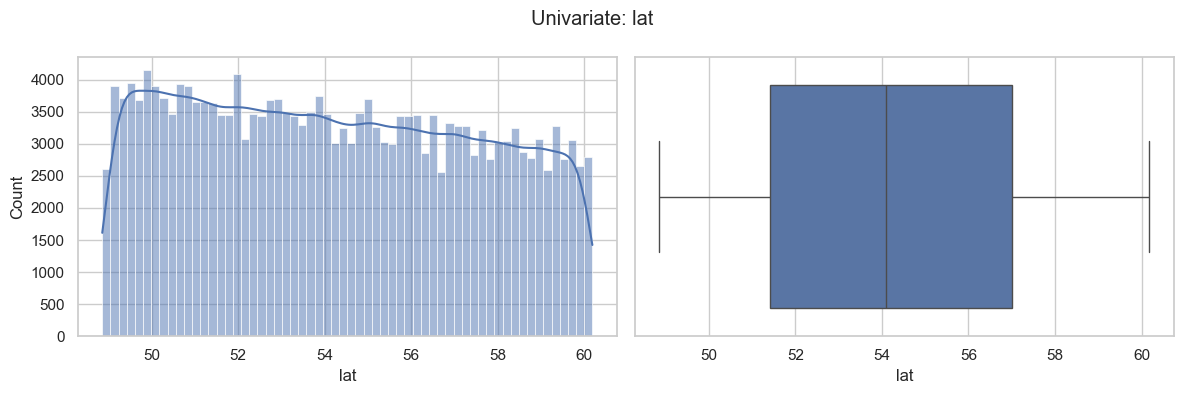

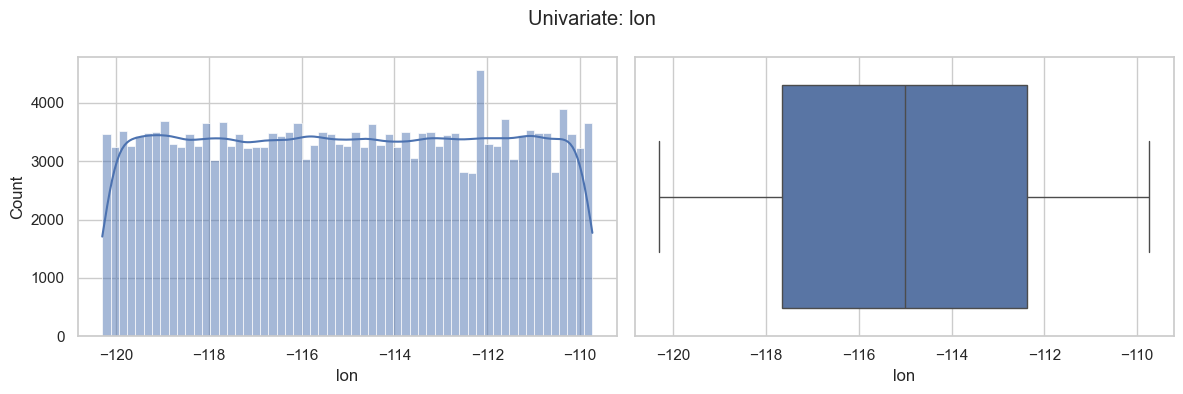

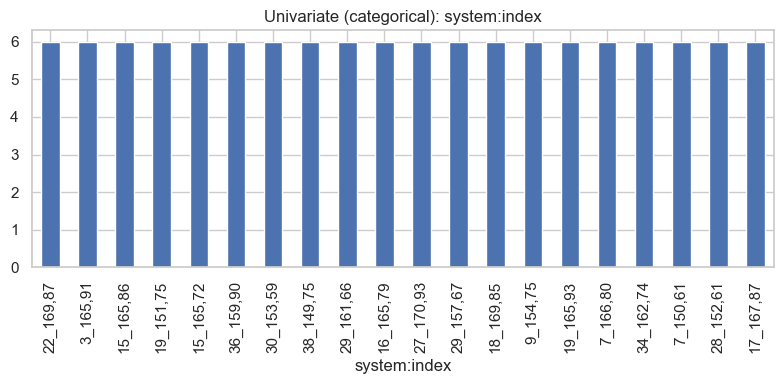

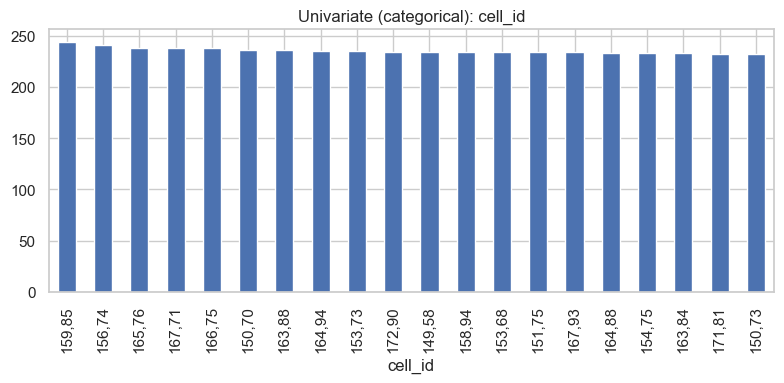

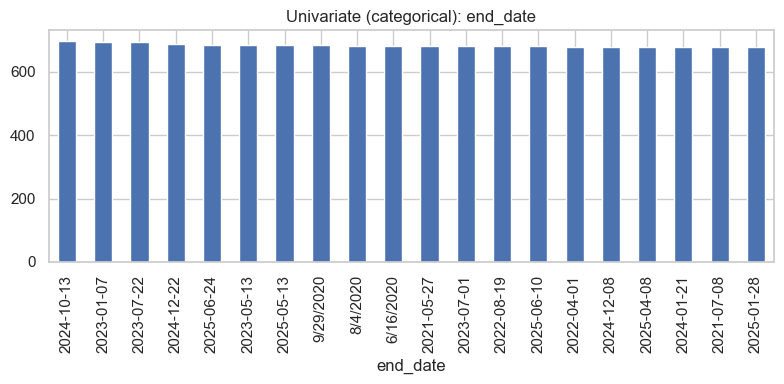

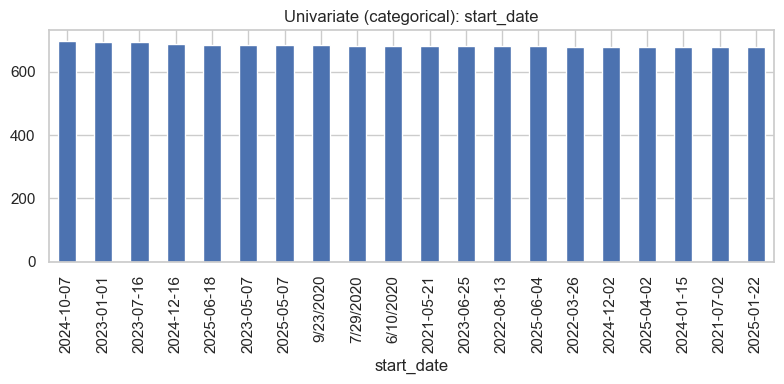

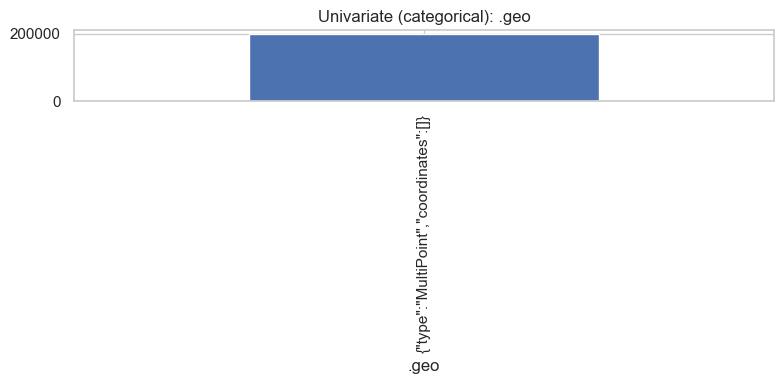

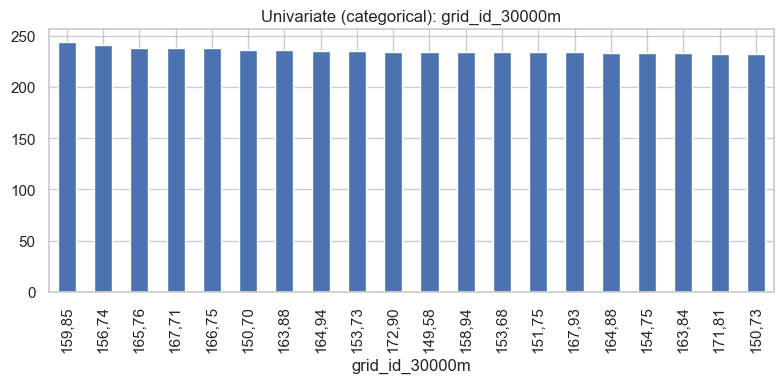

In [18]:
def split_columns(df: pd.DataFrame):
    num_cols = df.select_dtypes(include="number").columns.tolist()
    cat_cols = [c for c in df.columns if c not in num_cols]
    return num_cols, cat_cols


def plot_univariate(df: pd.DataFrame, max_num: int = 8, max_cat: int = 6, sample_rows: int = 200000):
    if df.empty:
        print("Empty dataset")
        return
    df_sample = df.sample(min(len(df), sample_rows), random_state=42)
    num_cols, cat_cols = split_columns(df_sample)

    for col in num_cols[:max_num]:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(df_sample[col].dropna(), kde=True, ax=axes[0])
        sns.boxplot(x=df_sample[col], ax=axes[1])
        fig.suptitle(f"Univariate: {col}")
        plt.tight_layout()
        plt.show()

    for col in cat_cols[:max_cat]:
        plt.figure(figsize=(8, 4))
        df_sample[col].value_counts().head(20).plot(kind="bar")
        plt.title(f"Univariate (categorical): {col}")
        plt.tight_layout()
        plt.show()


print("Univariate: merged dataset")
plot_univariate(df_model)

## 5. Bivariate analysis against wildfire event

Requires TARGET_COL to be set/detected.

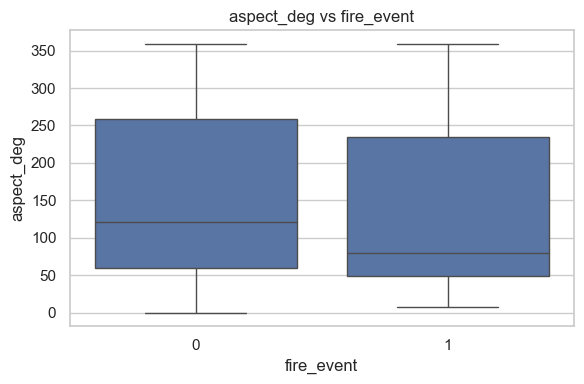

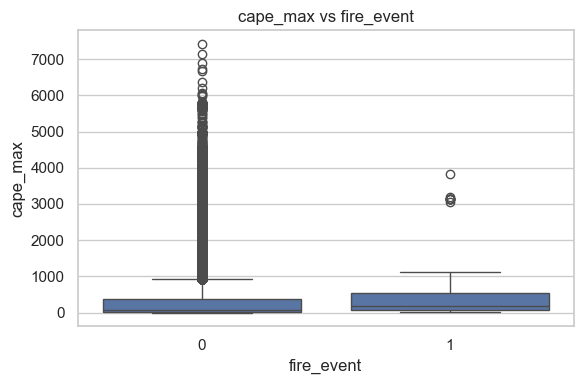

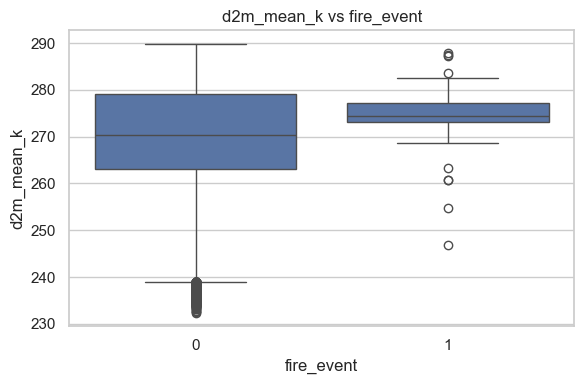

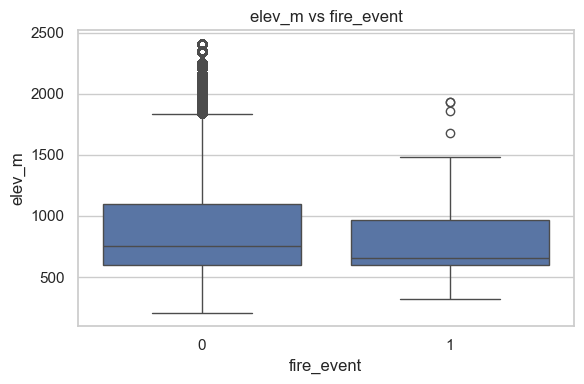

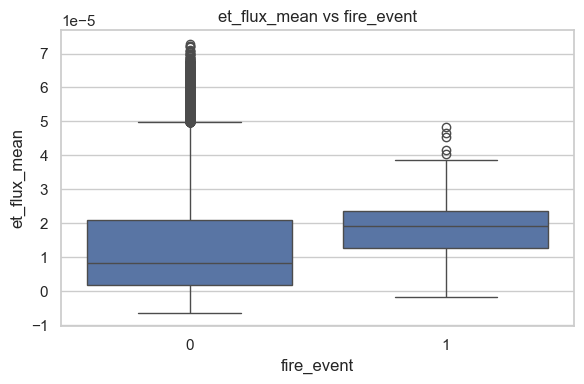

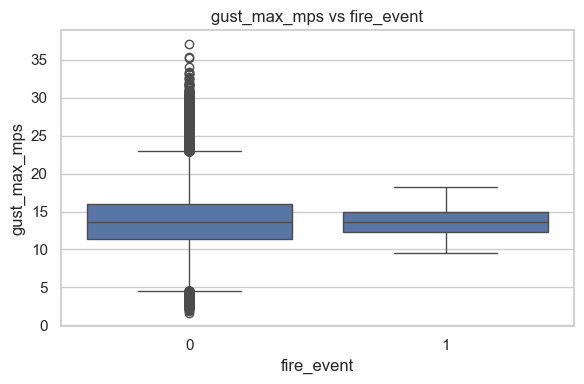

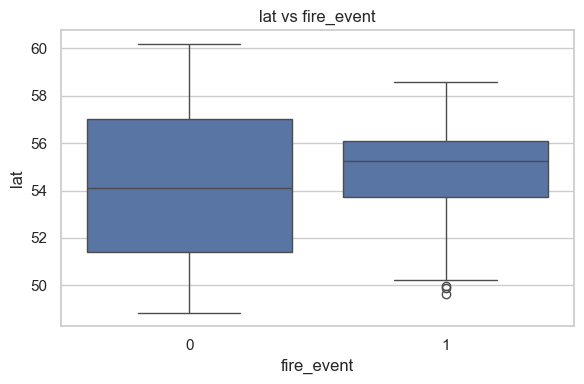

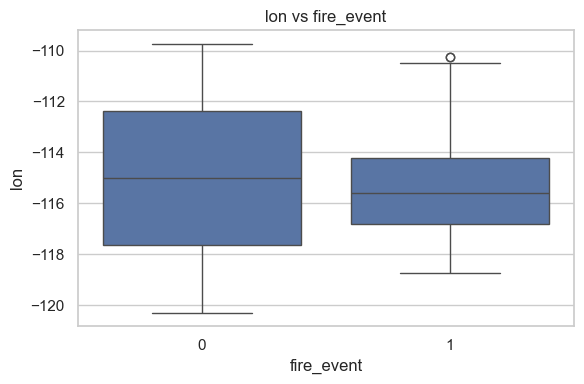

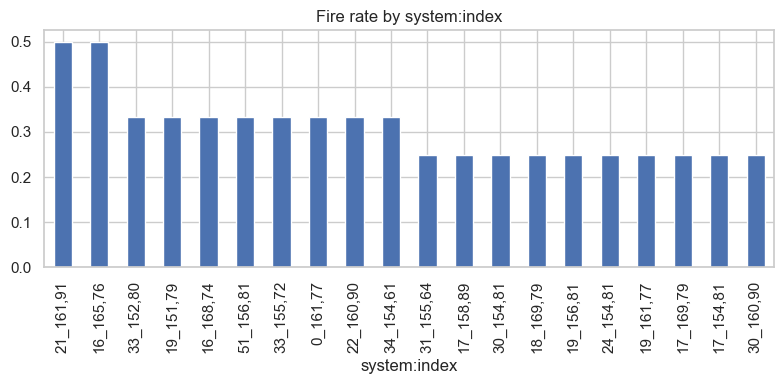

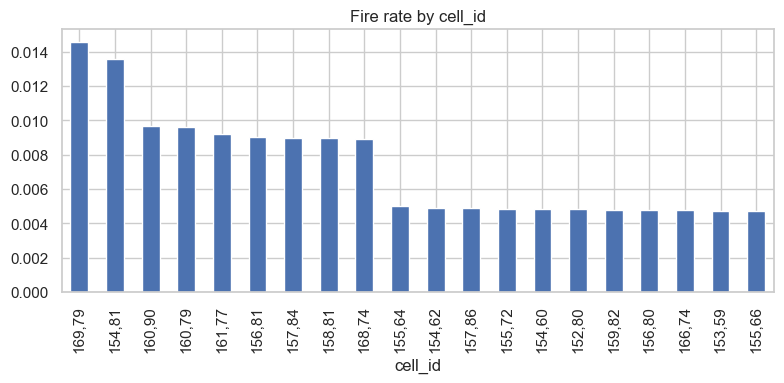

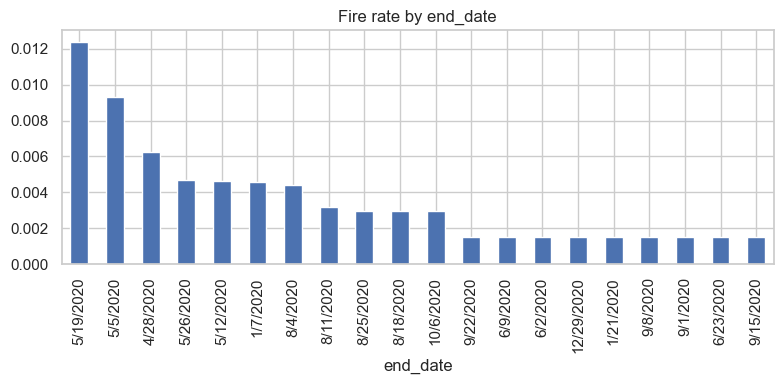

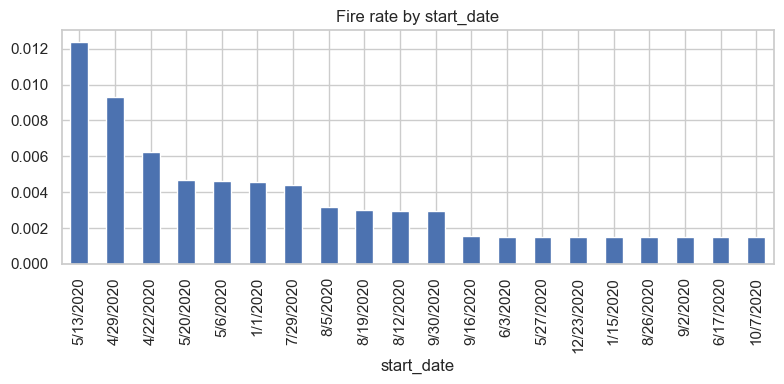

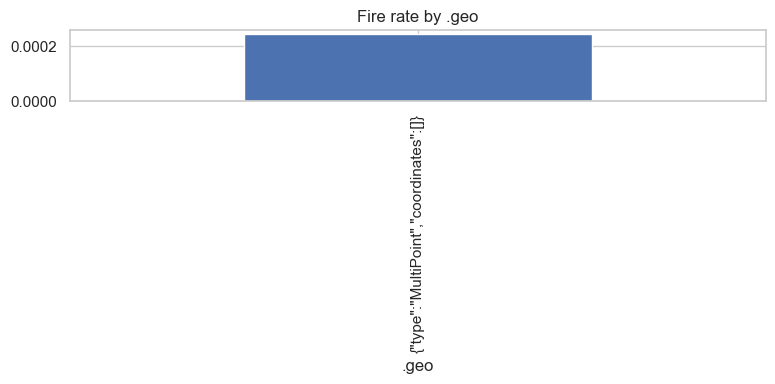

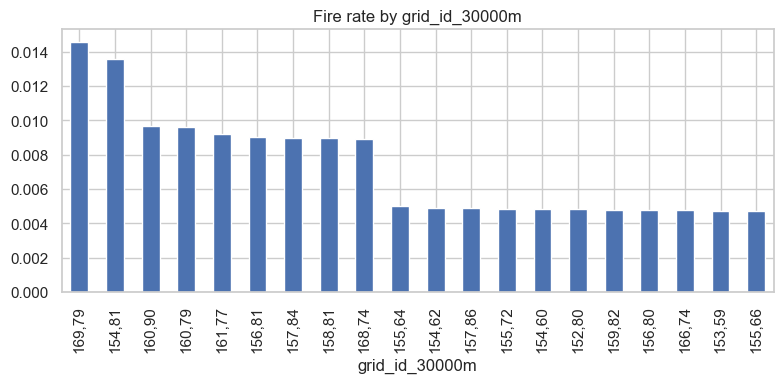

In [15]:
if TARGET_COL is None:
    print("Set TARGET_COL before running bivariate plots.")
else:
    df_sample = df_model.sample(min(len(df_model), 200000), random_state=42)
    num_cols, cat_cols = split_columns(df_sample.drop(columns=[TARGET_COL]))

    for col in num_cols[:8]:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=TARGET_COL, y=col, data=df_sample)
        plt.title(f"{col} vs {TARGET_COL}")
        plt.tight_layout()
        plt.show()

    for col in cat_cols[:6]:
        rate = df_sample.groupby(col)[TARGET_COL].mean().sort_values(ascending=False).head(20)
        plt.figure(figsize=(8, 4))
        rate.plot(kind="bar")
        plt.title(f"Fire rate by {col}")
        plt.tight_layout()
        plt.show()

## 6. Multivariate analysis and correlation matrix

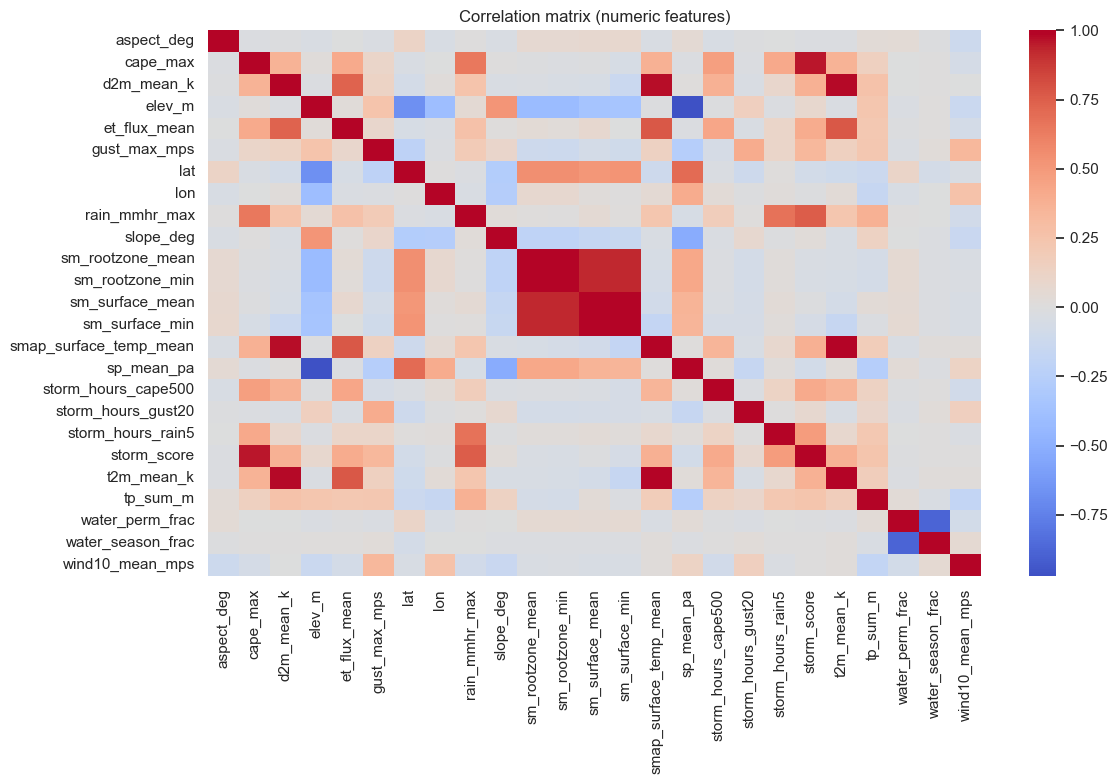

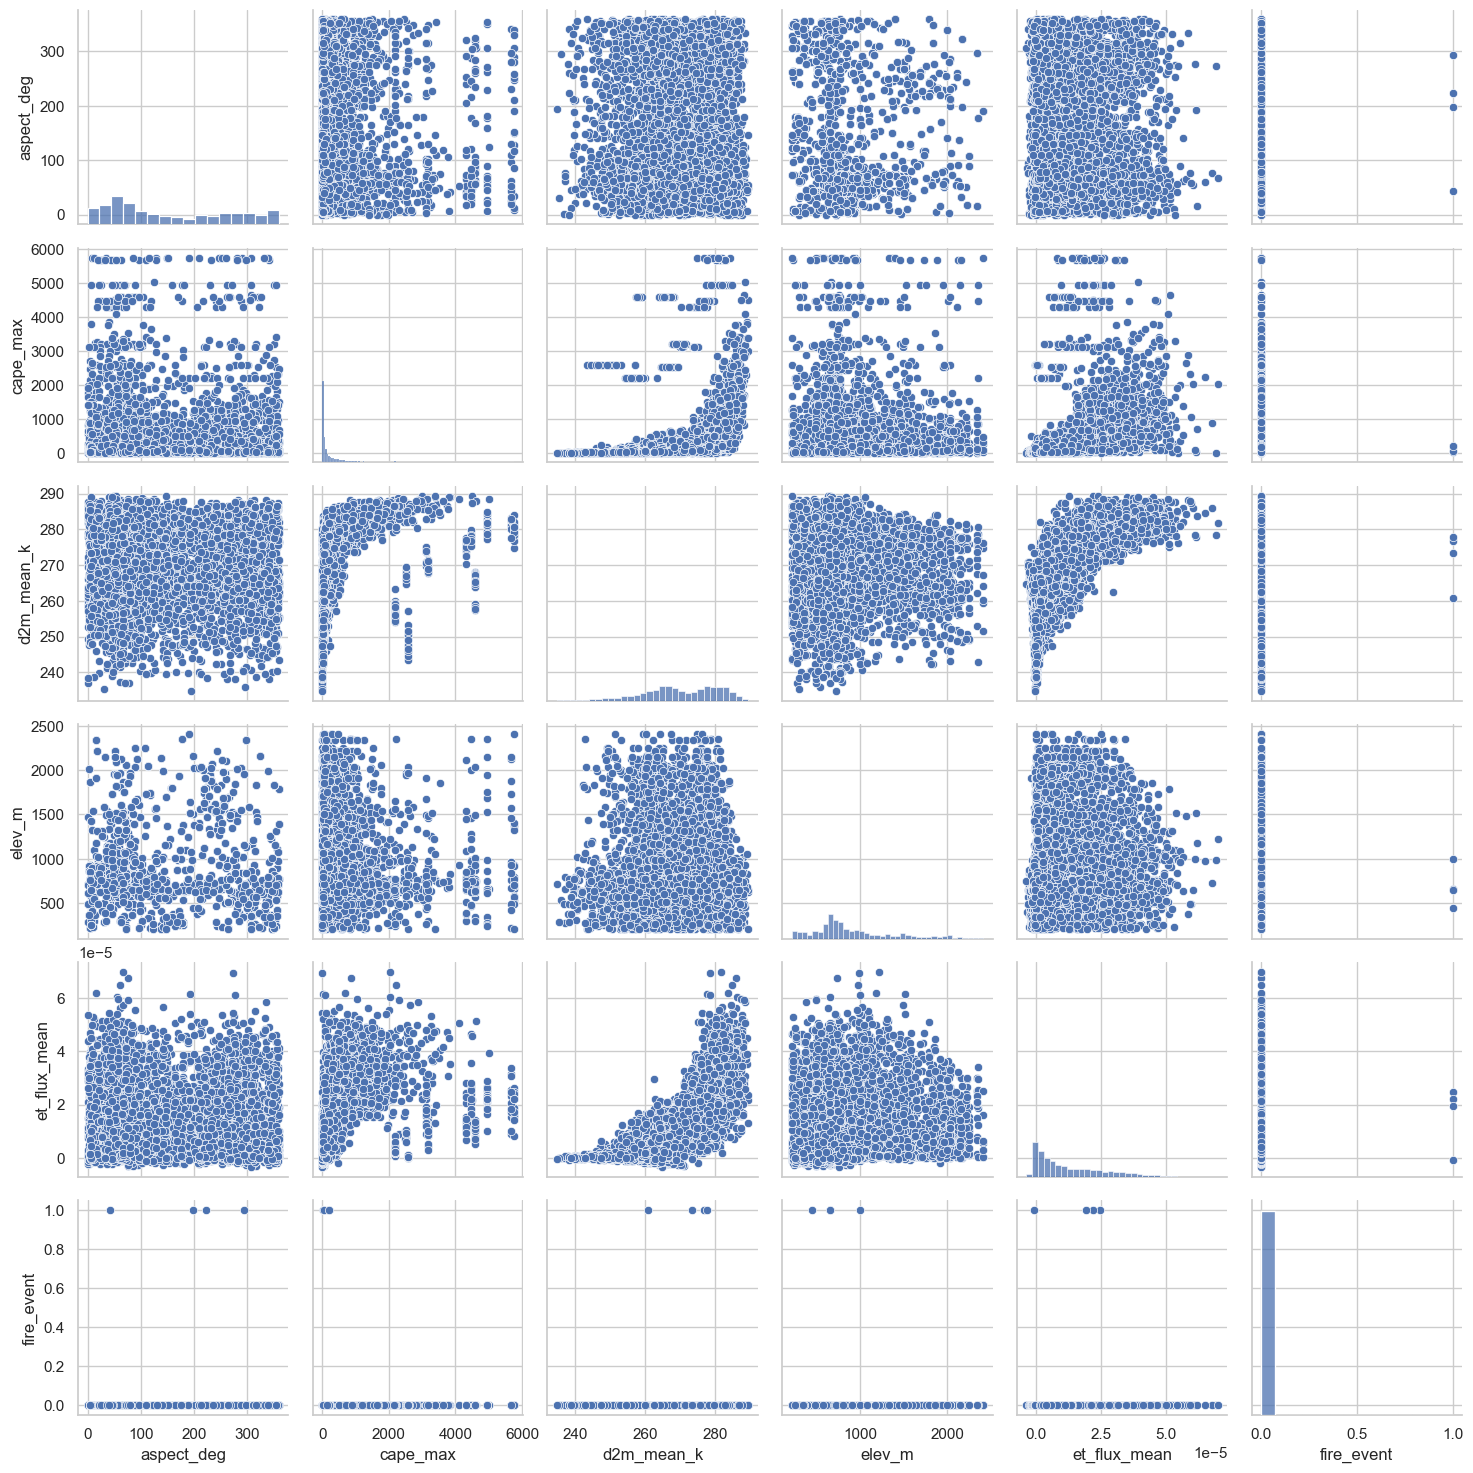

In [16]:
num_cols, _ = split_columns(df_model)
num_cols = [c for c in num_cols if c != TARGET_COL]

if len(num_cols) == 0:
    print("No numeric features available for correlation.")
else:
    corr = df_model[num_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0, cbar=True)
    plt.title("Correlation matrix (numeric features)")
    plt.tight_layout()
    plt.show()

    pair_cols = num_cols[:5]
    if TARGET_COL and TARGET_COL in df_model.columns:
        pair_cols = pair_cols + [TARGET_COL]
    if len(pair_cols) >= 2:
        sns.pairplot(df_model[pair_cols].dropna().sample(min(5000, len(df_model)), random_state=42))
        plt.show()

## 7. Feature importance with SHAP

Trains a tree-based classifier and explains feature influence on wildfire events.

AUC: 0.653


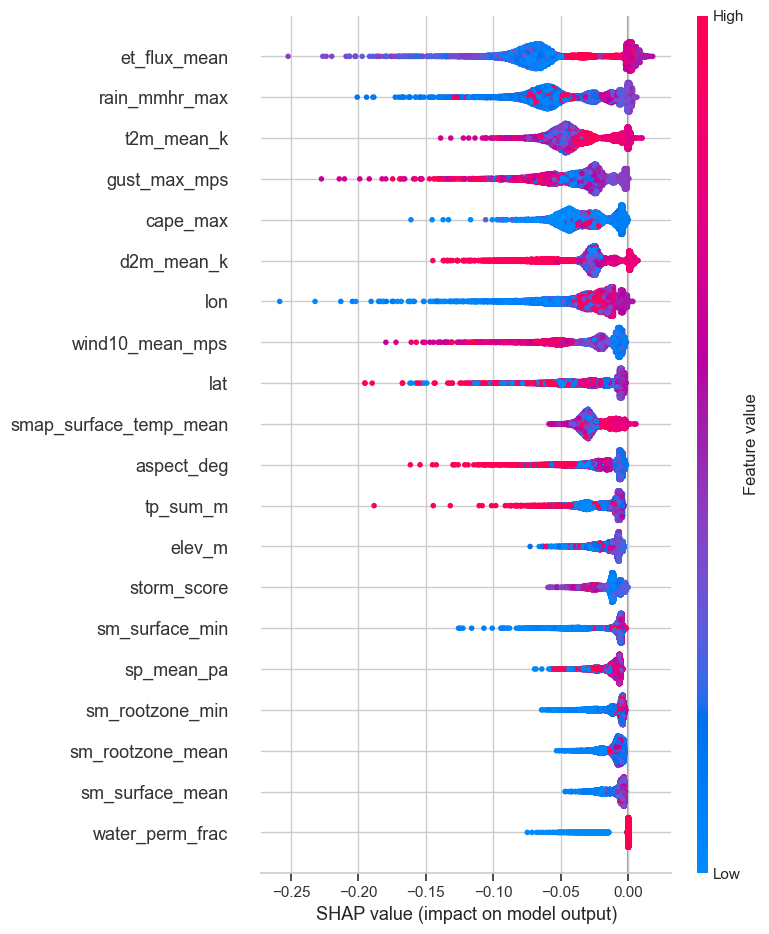

et_flux_mean              0.053606
rain_mmhr_max             0.043806
t2m_mean_k                0.038872
gust_max_mps              0.038443
cape_max                  0.031825
d2m_mean_k                0.030066
lon                       0.029269
wind10_mean_mps           0.025539
lat                       0.025405
smap_surface_temp_mean    0.024184
aspect_deg                0.019421
tp_sum_m                  0.018534
elev_m                    0.014612
storm_score               0.014247
sm_surface_min            0.013545
sp_mean_pa                0.012970
sm_rootzone_min           0.011071
sm_rootzone_mean          0.010269
sm_surface_mean           0.009755
water_perm_frac           0.006022
dtype: float64

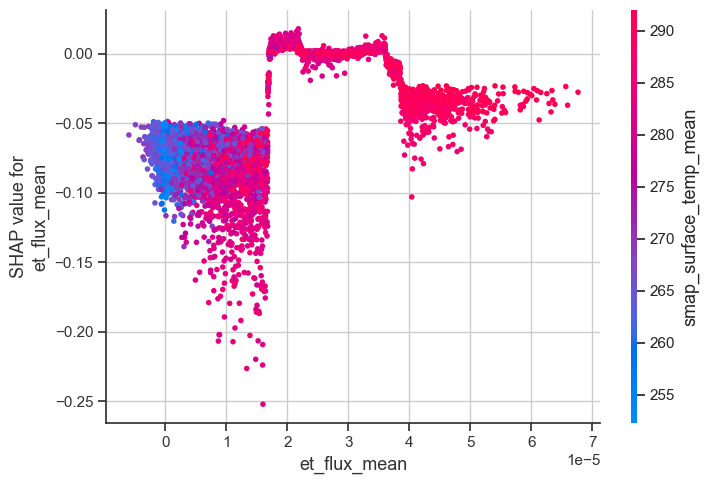

In [24]:
if TARGET_COL is None:
    print("Set TARGET_COL before running SHAP.")
else:
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import roc_auc_score

    X = df_model.drop(columns=[TARGET_COL]).copy()
    y = df_model[TARGET_COL]

    # Convert datetime columns to numeric timestamps
    datetime_cols = X.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns
    for col in datetime_cols:
        X[col] = pd.to_datetime(X[col], errors="coerce").astype("int64")

    # Use numeric features only to avoid huge one-hot expansion
    X = X.select_dtypes(include="number")
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    if X.shape[1] == 0:
        raise ValueError("No usable numeric features after preprocessing.")

    if y.nunique() < 2:
        raise ValueError("Target has only one class. Check TARGET_COL or join logic.")

    # Downsample for SHAP to reduce memory (stratified)
    max_rows = 50000
    if len(X) > max_rows:
        X, _, y, _ = train_test_split(
            X, y, train_size=max_rows, random_state=42, stratify=y
        )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    )
    model.fit(X_train, y_train)

    if len(model.classes_) < 2:
        raise ValueError("Model trained with a single class. Recheck TARGET_COL and class balance.")

    class_index = list(model.classes_).index(1) if 1 in model.classes_ else 0
    preds = model.predict_proba(X_test)[:, class_index]
    print(f"AUC: {roc_auc_score(y_test, preds):.3f}")

    try:
        import shap

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)

        # Normalize SHAP output to (n_samples, n_features)
        if isinstance(shap_values, list):
            shap_values = shap_values[class_index]
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            shap_values = shap_values[:, :, class_index]
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim != 2:
            raise ValueError(f"Unexpected SHAP shape: {shap_values.shape}")

        shap.summary_plot(shap_values, X_test, show=False)
        plt.tight_layout()
        plt.show()

        # Store mean absolute SHAP for later feature reduction
        shap_importance = pd.Series(
            np.abs(shap_values).mean(axis=0), index=X_test.columns
        ).sort_values(ascending=False)
        display(shap_importance.head(20))

        # Dependence plot for the top feature
        top_feature = shap_importance.index[0]
        try:
            shap.dependence_plot(top_feature, shap_values, X_test, show=False)
            plt.tight_layout()
            plt.show()
        except Exception as exc:
            print(f"SHAP dependence plot skipped: {exc}")
    except Exception as exc:
        print(f"SHAP failed: {exc}")
        shap_importance = None

## 8. Threshold analysis for fire risk

Suggest thresholds by binning each feature and finding bins with elevated fire rate.

In [19]:
def threshold_analysis(df: pd.DataFrame, target: str, features: list[str], bins: int = 10):
    results = []
    for col in features:
        if col == target:
            continue
        series = pd.to_numeric(df[col], errors="coerce")
        if series.notna().sum() < bins:
            continue
        try:
            binned = pd.qcut(series, q=bins, duplicates="drop")
        except ValueError:
            continue
        rates = df.groupby(binned)[target].mean().dropna()
        if rates.empty:
            continue
        top_bin = rates.idxmax()
        results.append({
            "feature": col,
            "top_bin": str(top_bin),
            "max_fire_rate": rates.max(),
        })
    return pd.DataFrame(results).sort_values("max_fire_rate", ascending=False)


if TARGET_COL is None:
    print("Set TARGET_COL before threshold analysis.")
else:
    num_cols, _ = split_columns(df_model)
    num_cols = [c for c in num_cols if c != TARGET_COL]
    thresh_df = threshold_analysis(df_model, TARGET_COL, num_cols, bins=8)
    display(thresh_df.head(15))

C:\Users\Angie\AppData\Local\Temp\ipykernel_4792\766619936.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df.groupby(binned)[target].mean().dropna()
C:\Users\Angie\AppData\Local\Temp\ipykernel_4792\766619936.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df.groupby(binned)[target].mean().dropna()
C:\Users\Angie\AppData\Local\Temp\ipykernel_4792\766619936.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence th

,feature,top_bin,max_fire_rate
14,smap_surface_temp_mean,"(275.376, 281.942]",0.001053
20,t2m_mean_k,"(276.352, 282.481]",0.000910
2,d2m_mean_k,"(270.456, 275.434]",0.000797
4,et_flux_mean,"(1.36e-05, 2.1e-05]",0.000768
6,lat,"(54.111, 55.517]",0.000707
10,sm_rootzone_mean,"(0.271, 0.353]",0.000683
11,sm_rootzone_min,"(0.267, 0.351]",0.000654
12,sm_surface_mean,"(0.239, 0.285]",0.000597
13,sm_surface_min,"(0.223, 0.271]",0.000541
8,rain_mmhr_max,"(2.503, 21.172]",0.000541


## 9. Reduce/eliminate non-important variables and save cleaned data

Drops low-importance features (from SHAP) and saves a cleaned dataset.

In [25]:
TARGET_COL = globals().get("TARGET_COL")
shap_importance = globals().get("shap_importance")
df_model = globals().get("df_model")
BASE = globals().get("BASE")

if TARGET_COL is None and df_model is not None:
    candidates = [
        c
        for c in df_model.columns
        if any(k in c for k in ["fire", "wildfire", "burn", "event", "is_fire"])
    ]
    if candidates:
        TARGET_COL = candidates[0]

if shap_importance is None:
    if TARGET_COL is None:
        print("Set TARGET_COL before feature reduction (or run the target-detect cell).")
    else:
        print("Run the SHAP section first to compute feature importance.")
elif df_model is None or BASE is None:
    print("Run the data prep section to set df_model and BASE.")
else:
    cutoff = shap_importance.quantile(0.20)
    low_importance = shap_importance[shap_importance <= cutoff].index
    print(f"Dropping {len(low_importance)} low-importance features")

    reduced_df = df_model.copy()
    reduced_df = reduced_df.drop(columns=[c for c in low_importance if c in reduced_df.columns])

    out_dir = BASE / "derived"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / "wildfire_features_cleaned.parquet"
    reduced_df.to_parquet(out_path, index=False)
    print(f"Saved: {out_path}")

Dropping 5 low-importance features
Saved: C:\Users\Angie\Downloads\paragon\Paragon\archive\Angie\derived\wildfire_features_cleaned.parquet
